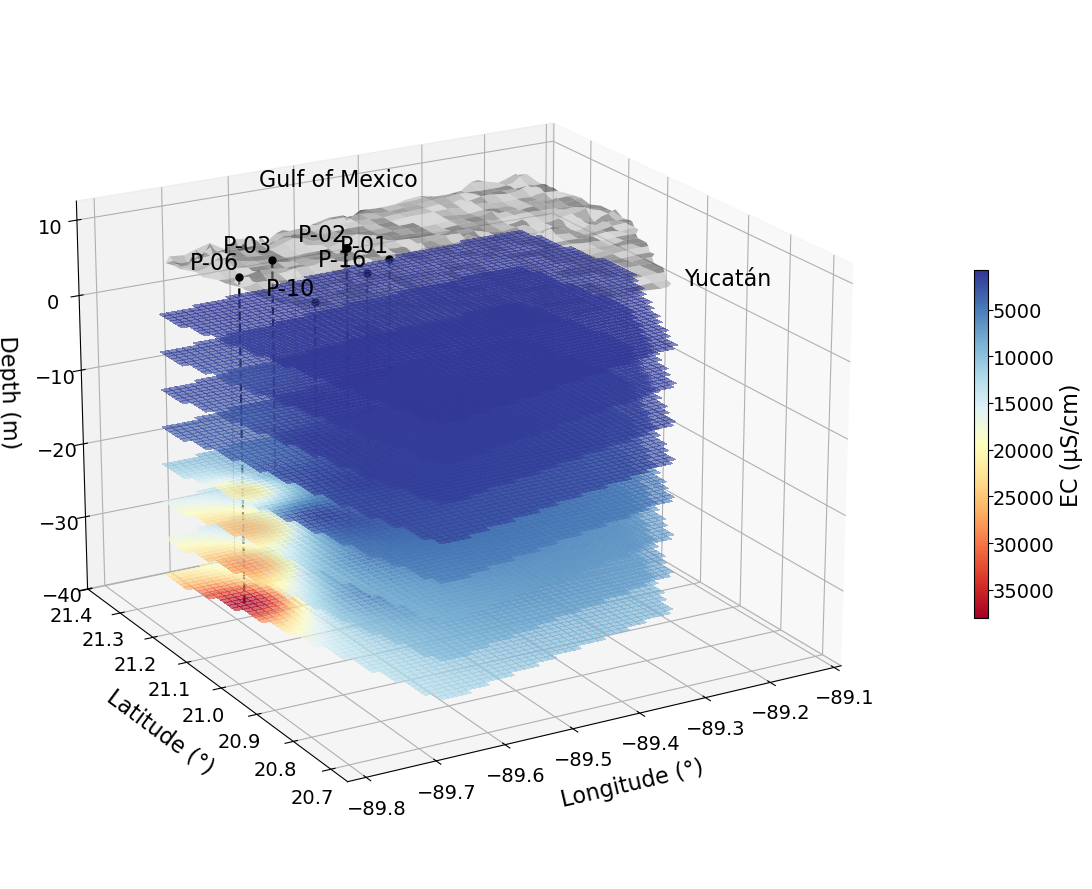

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from shapely import contains_xy, force_2d
from matplotlib import cm
from pyproj import CRS, Transformer
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

df = pd.read_excel("../datos_.xlsx", "Hoja4",usecols=["EST sonda","x","y","Profundidad    (m)","Conductividad corregida"])
df = df.rename(columns={"Profundidad    (m)": "Prof", "Conductividad corregida": "Cond"})
for c in ["x","y","Prof","Cond"]:df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df = df.dropna(subset=["x","y","Prof","Cond"])
g = gpd.read_file("../__QGIS/area_Y.shp")
g["geometry"] = g.geometry.apply(force_2d)
xmin, ymin, xmax, ymax = g.total_bounds
nx = 60
ny = max(20, int(nx * (ymax - ymin) / max(1e-9, (xmax - xmin))))
Xll, Yll = np.meshgrid(np.linspace(xmin, xmax, nx),np.linspace(ymin, ymax, ny))
geom_union = g.union_all() if hasattr(g, "union_all") else g.unary_union
mask = contains_xy(geom_union, Xll, Yll)
with rasterio.open("../__QGIS/MDT_MEX.tif") as r: 
    S = np.array([v[0] for v in r.sample(np.c_[Xll.ravel(), Yll.ravel()])]).reshape(Xll.shape)
    S = np.where(mask & np.isfinite(S), S, np.nan)
def idw(xy, v, Xg, Yg, p=2, eps=1e-12):
    xy, v = np.asarray(xy), np.asarray(v)
    dx, dy = Xg[..., None] - xy[:, 0], Yg[..., None] - xy[:, 1]
    w = 1.0 / ((dx*dx + dy*dy + eps)**(p/2))
    return (w * v).sum(2) / w.sum(2)
depth_targets = np.arange(0, 40.000001, 5.0)
g_by = df.sort_values(["EST sonda", "Prof"]).groupby("EST sonda")
slices, valid_depths = [], []
for d in depth_targets:
    xy, vv = [], []
    for _, gpo in g_by:
        if gpo.Prof.min() <= d <= gpo.Prof.max():
            xy.append([gpo.x.iloc[0], gpo.y.iloc[0]])
            vv.append(np.interp(d, gpo.Prof.to_numpy(), gpo.Cond.to_numpy()))
    if len(vv) >= 3:
        Z = np.where(mask, idw(np.asarray(xy), np.asarray(vv), Xll, Yll), np.nan)
        slices.append(Z)
        valid_depths.append(d)
cond3d = np.stack([z.T for z in slices], axis=-1)  # (nx, ny, nz_coarse)
new_depths = np.arange(valid_depths[0], valid_depths[-1] + 1e-9, 1.0)
nz = len(new_depths)
cond3d_hi = np.full((nx, ny, nz), np.nan)
for ix in range(nx):
    for iy in range(ny):
        col = cond3d[ix, iy, :]
        if np.any(np.isfinite(col)):cond3d_hi[ix, iy, :] = np.interp(new_depths, valid_depths, col, left=np.nan, right=np.nan)
cond3d = cond3d_hi  # (nx, ny, nz)
vmin = np.nanmin(cond3d)
vmax = np.nanmax(cond3d)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.RdYlBu_r
Smin, Smax = np.nanmin(S), np.nanmax(S)
S_norm = (S - Smin) / max(1e-9, (Smax - Smin))
top_z = 8.0                     # altura base del “techo” (m)
terrain_amp = 2.5               # relieve vertical (m)
Z_terrain = top_z + terrain_amp * (S_norm - np.nanmean(S_norm))

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.set_title("", fontsize=20, pad=14)
ax.plot_surface(Xll, Yll, Z_terrain,color=(0.8, 0.8, 0.8, 0.6),edgecolor="none", linewidth=0, antialiased=True, shade=True, zorder=0)
slice_every_m = 5
depths_to_plot = np.arange(new_depths[0], new_depths[-1] + 1e-9, slice_every_m)
for d in depths_to_plot:
    iz = int(np.argmin(np.abs(new_depths - d)))  # índice más cercano
    C = cond3d[:, :, iz].T                       # (ny, nx) para coincidir con X_m0/Y_m0
    valid = np.isfinite(C) & mask
    Zp = -float(new_depths[iz]) * np.ones_like(Xll)
    fc = cmap(norm(np.nan_to_num(C, nan=vmin)))
    fc[..., 3] = np.where(valid, 0.6, 0.0)      # alpha: visible solo donde hay datos
    ax.plot_surface(Xll, Yll, Zp,facecolors=fc,rstride=1, cstride=1,edgecolor="none", linewidth=0,antialiased=False, shade=False)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array(cond3d[np.isfinite(cond3d)])
cbar = plt.colorbar(sm, ax=ax, pad=0.08, shrink=0.4, aspect=25, label="EC (µS/cm)")
cbar.ax.tick_params(labelsize=14, pad=0)
cbar.set_label("EC (µS/cm)", fontsize=16)
cbar.ax.invert_yaxis()
for est, gpo in df.groupby("EST sonda"):
    lon = float(gpo["x"].iloc[0]);lat = float(gpo["y"].iloc[0])
    ix = int(np.nanargmin(np.abs(Xll[0, :] - lon)))
    iy = int(np.nanargmin(np.abs(Yll[:, 0] - lat)))
    z_top = float(Z_terrain[iy, ix])
    dmax = float(gpo["Prof"].max())
    z_bottom = -np.clip(dmax, new_depths[0], new_depths[-1])
    ax.plot([lon, lon], [lat, lat], [z_top, z_bottom], "--", color="black", lw=1.6, alpha=1)
    ax.plot([lon], [lat], [z_top], "o", color="black", ms=5, zorder=10)
    ax.text(lon, lat, z_top + 0.3, str(est), fontsize=16, ha="right", va="bottom", zorder=100)
ax.set_xlabel("Longitude (°)", fontsize=16, labelpad=12)
ax.set_ylabel("Latitude (°)", fontsize=16, labelpad=12)
ax.set_zlabel("Depth (m)", fontsize=16, labelpad=12)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='z', labelsize=14)
# --- Text labels using fractional (0–1) positions ---
valid = np.isfinite(Z_terrain) & mask
yy, xx = np.argwhere(valid).T

# Gulf of Mexico @ (x=0.40, y=0.80) with z offset +0.1
ix, iy = int(0.40*(nx-1)), int(0.80*(ny-1))
k = np.argmin((xx-ix)**2 + (yy-iy)**2)
ix, iy = int(xx[k]), int(yy[k])
ax.text(Xll[iy, ix], Yll[iy, ix], Z_terrain[iy, ix] + 6, "Gulf of Mexico",
        ha="center", va="bottom", fontsize=16, clip_on=False)

# Yucatán @ (x=0.65, y=0.35) with z offset +0.1
ix, iy = int(0.65*(nx-1)), int(0.35*(ny-1))
k = np.argmin((xx-ix)**2 + (yy-iy)**2)
ix, iy = int(xx[k]), int(yy[k])
ax.text(Xll[iy, ix], Yll[iy, ix]-0.3, Z_terrain[iy, ix] + 6, "Yucatán",
        ha="left", va="bottom", fontsize=16, clip_on=False)
ax.set_zlim(-new_depths[-1] - 5, top_z + terrain_amp + 2)
ax.view_init(elev=20, azim=-120)
plt.tight_layout()
fig.savefig("7_capas_Y.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/f6/wfrnxqf108nbx2nvsph0n70h0000gn/T/ipykernel_3212/3928434933.py:119: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


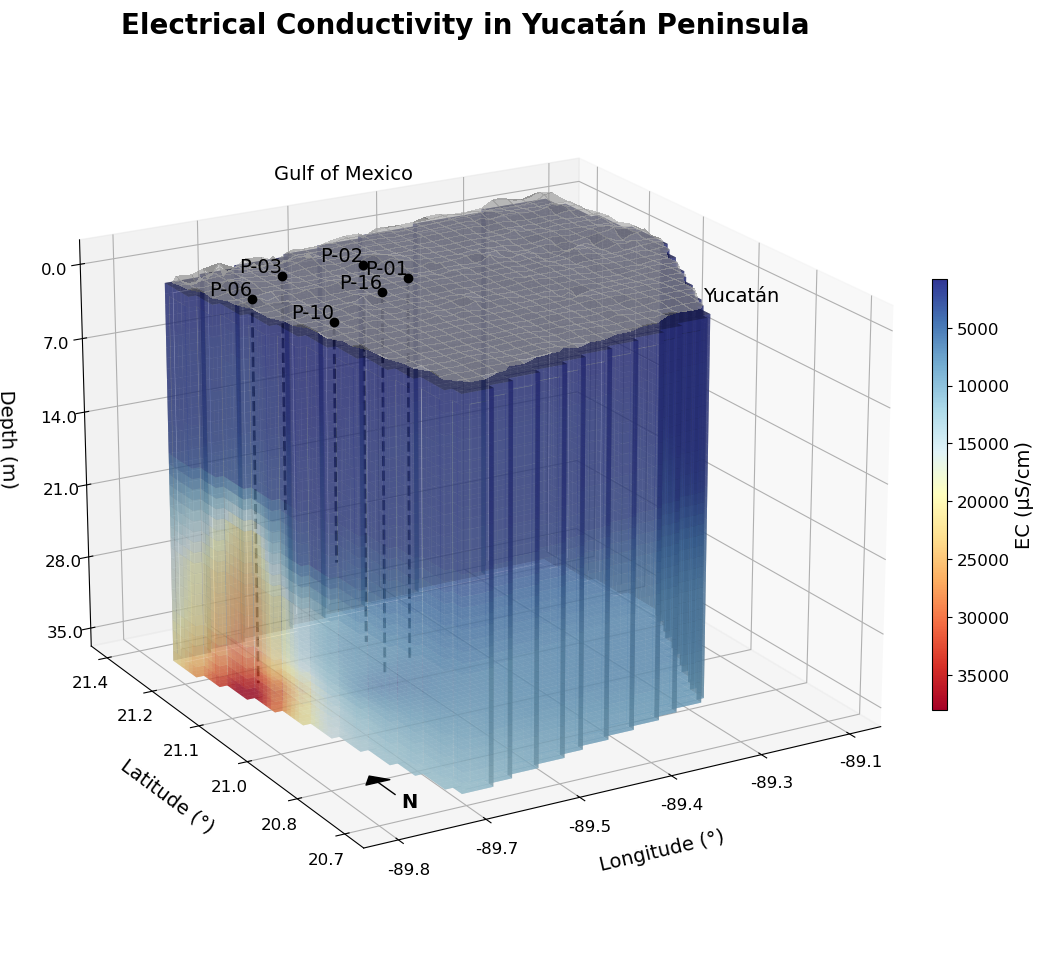

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from shapely import contains_xy, force_2d
from matplotlib import cm
from pyproj import CRS
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

df = pd.read_excel("../datos_.xlsx", "Hoja4",usecols=["EST sonda","x","y","Profundidad    (m)","Conductividad corregida"])
df = df.rename(columns={"Profundidad    (m)": "Prof","Conductividad corregida": "Cond"})
for c in ["x", "y", "Prof", "Cond"]:df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df = df.dropna(subset=["x", "y", "Prof", "Cond"])
g = gpd.read_file("../__QGIS/area_Y.shp")
g["geometry"] = g.geometry.apply(force_2d)
xmin, ymin, xmax, ymax = g.total_bounds
nx = 60
ny = max(20, int(nx * (ymax - ymin) / max(1e-9, (xmax - xmin))))
Xll, Yll = np.meshgrid(np.linspace(xmin, xmax, nx),np.linspace(ymin, ymax, ny))
geom_union = g.union_all() if hasattr(g, "union_all") else g.unary_union
mask = contains_xy(geom_union, Xll, Yll)
with rasterio.open("../__QGIS/MDT_MEX.tif") as r:S = np.array([v[0] for v in r.sample(np.c_[Xll.ravel(), Yll.ravel()])]).reshape(Xll.shape)
S = np.where(mask & np.isfinite(S), S, np.nan)
def idw(xy, v, Xg, Yg, p=2, eps=1e-12):
    xy, v = np.asarray(xy), np.asarray(v)
    dx, dy = Xg[..., None] - xy[:, 0], Yg[..., None] - xy[:, 1]
    w = 1.0 / ((dx*dx + dy*dy + eps)**(p/2))
    return (w * v).sum(2) / w.sum(2)
depth_targets = np.arange(0, 40.000001, 5.0)
g_by = df.sort_values(["EST sonda", "Prof"]).groupby("EST sonda")
slices, valid_depths = [], []
for d in depth_targets:
    xy, vv = [], []
    for _, gpo in g_by:
        if gpo.Prof.min() <= d <= gpo.Prof.max():
            xy.append([gpo.x.iloc[0], gpo.y.iloc[0]])
            vv.append(np.interp(d, gpo.Prof.to_numpy(), gpo.Cond.to_numpy()))
    if len(vv) >= 3:
        Z = np.where(mask, idw(np.asarray(xy), np.asarray(vv), Xll, Yll), np.nan)
        slices.append(Z)
        valid_depths.append(d)
cond3d = np.stack([z.T for z in slices], axis=-1)  # (nx, ny, nz_coarse)
new_depths = np.arange(valid_depths[0], valid_depths[-1] + 1e-9, 1.0)
nz = len(new_depths)
cond3d_hi = np.full((nx, ny, nz), np.nan)
for ix in range(nx):
    for iy in range(ny):
        col = cond3d[ix, iy, :]
        if np.any(np.isfinite(col)):
            cond3d_hi[ix, iy, :] = np.interp(new_depths, valid_depths, col, left=np.nan, right=np.nan)
cond3d = cond3d_hi
filled = np.isfinite(cond3d)
norm = plt.Normalize(vmin=np.nanmin(cond3d), vmax=np.nanmax(cond3d))
fc = cm.RdYlBu_r(norm(np.nan_to_num(cond3d, nan=np.nanmin(cond3d))))
fc[..., 3] = np.where(filled, 0.6, 0.0)

fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection="3d")
ax.voxels(filled, facecolors=fc, edgecolor="k", linewidth=0)
sm = cm.ScalarMappable(norm=norm, cmap=cm.RdYlBu_r)
sm.set_array(cond3d[np.isfinite(cond3d)])
cbar = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.4, aspect=30)
cbar.ax.invert_yaxis()
cbar.set_label("EC (µS/cm)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
z_ticks = np.linspace(0, nz-1, min(nz, 6)).astype(int)
xt = np.linspace(0, nx-1, min(nx, 6)).astype(int)
yt = np.linspace(0, ny-1, min(ny, 6)).astype(int)
ax.set(xticks=xt,yticks=yt,zticks=z_ticks,zticklabels=[f"{new_depths[i]:.1f}" for i in z_ticks])
ax.set_title("Electrical Conductivity in Yucatán", fontsize=20, fontweight="bold", pad=-30)
ax.set_xticklabels([f"{Xll[0, i]:.1f}"  for i in xt])
ax.set_yticklabels([f"{Yll[j, 0]:.1f}" for j in yt])
Xsurf, Ysurf = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")
Smin, Smax = np.nanmin(S), np.nanmax(S)
S_norm = (S - Smin) / max(1e-9, (Smax - Smin))
ax.plot_surface(Xsurf,Ysurf,-1.5 * S_norm,color=(0.8, 0.8, 0.8, 0.6),edgecolor="none",linewidth=0,antialiased=False,shade=True)
ix = int(np.nanargmin(np.abs(Xll[0] - -89.5)));iy = int(np.nanargmin(np.abs(Yll[:, 0] - 21.5)))
if not np.isfinite(S_norm[iy, ix]):yy, xx = np.argwhere(np.isfinite(S_norm)).T;k = np.argmin((xx - ix)**2 + (yy - iy)**2);ix, iy = int(xx[k]), int(yy[k])
z0 = -1.5 * S_norm[iy, ix] - 5
ax.text(ix, iy, z0, "Gulf of Mexico", ha="center", va="bottom", clip_on=False, fontsize=14)
ix = int(np.nanargmin(np.abs(Xll[0] + 89.1)));  iy = int(np.nanargmin(np.abs(Yll[:, 0] - 20.78)))
if not np.isfinite(S_norm[iy, ix]):yy, xx = np.argwhere(np.isfinite(S_norm)).T; k = np.argmin((xx - ix)**2 + (yy - iy)**2); ix, iy = int(xx[k]), int(yy[k])
z0 = -1.5 * S_norm[iy, ix] + 0
ax.text(ix, iy, z0, "Yucatán", ha="left", va="bottom", clip_on=False, fontsize=14)
ix_anchor = nx * 0.01;iy_anchor = ny * 0.1; iz_top = 35;arrow_scale_idx = 2 
p1 = (ix_anchor + arrow_scale_idx * 0.5, iy_anchor, iz_top)
p2 = (ix_anchor + arrow_scale_idx * 2.0, iy_anchor, iz_top)
p3 = (ix_anchor + arrow_scale_idx * 1.25, iy_anchor + arrow_scale_idx, iz_top)
ax.add_collection3d(Poly3DCollection([[p1, p2, p3]], edgecolor="k", facecolor="k", linewidths=1))
x_mid = ix_anchor + arrow_scale_idx * 1.25
y_end = iy_anchor - arrow_scale_idx * 2
ax.plot([x_mid, x_mid], [iy_anchor, y_end], [iz_top, iz_top], color="k", lw=1)
y_text = y_end + arrow_scale_idx * 0.25
ax.text(x_mid+ arrow_scale_idx * 1.01, y_text, iz_top+2, "N", color="k", fontsize=14, fontweight="bold", ha="center", va="bottom", clip_on=False)
for est, gpo in df.groupby("EST sonda"):
    x_est = gpo.x.iloc[0];y_est = gpo.y.iloc[0]
    ix = int(np.nanargmin(np.abs(Xll[0] - x_est)));iy = int(np.nanargmin(np.abs(Yll[:, 0] - y_est)))
    if not np.isfinite(S_norm[iy, ix]):
        yy, xx = np.argwhere(np.isfinite(S_norm)).T
        k = np.argmin((xx - ix)**2 + (yy - iy)**2)
        ix, iy = int(xx[k]), int(yy[k])
    z_top = -1.5 * S_norm[iy, ix]
    d_max = gpo.Prof.max()
    d_clamped = np.clip(d_max, new_depths[0], new_depths[-1])
    iz_bottom = float(np.interp(d_clamped, new_depths, np.arange(nz)))
    ax.plot([ix, ix],[iy, iy],[z_top, iz_bottom],"--",alpha=1,color="k",lw=2,)
    ax.plot([ix],[iy],-1,"o",color="k",alpha=1,lw=1,zorder=10000000,)
    for xg, yg, zg, name in zip([ix], [iy], [-1], [gpo["EST sonda"].iloc[0]]):
        ax.text(xg, yg, zg, str(name),ha="right", va="bottom", fontsize=14,zorder=10000000000, clip_on=False)
ax.set_xlabel("Longitude (°)", fontsize=14, labelpad=14)
ax.set_ylabel("Latitude (°)", fontsize=14, labelpad=14)
ax.set_zlabel("Depth (m)", fontsize=14, labelpad=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='z', labelsize=12)
ax.invert_zaxis()
ax.view_init(elev=20, azim=-120)
plt.tight_layout()
fig.savefig("7_3D_Y.png", dpi=300, bbox_inches="tight")
plt.show()

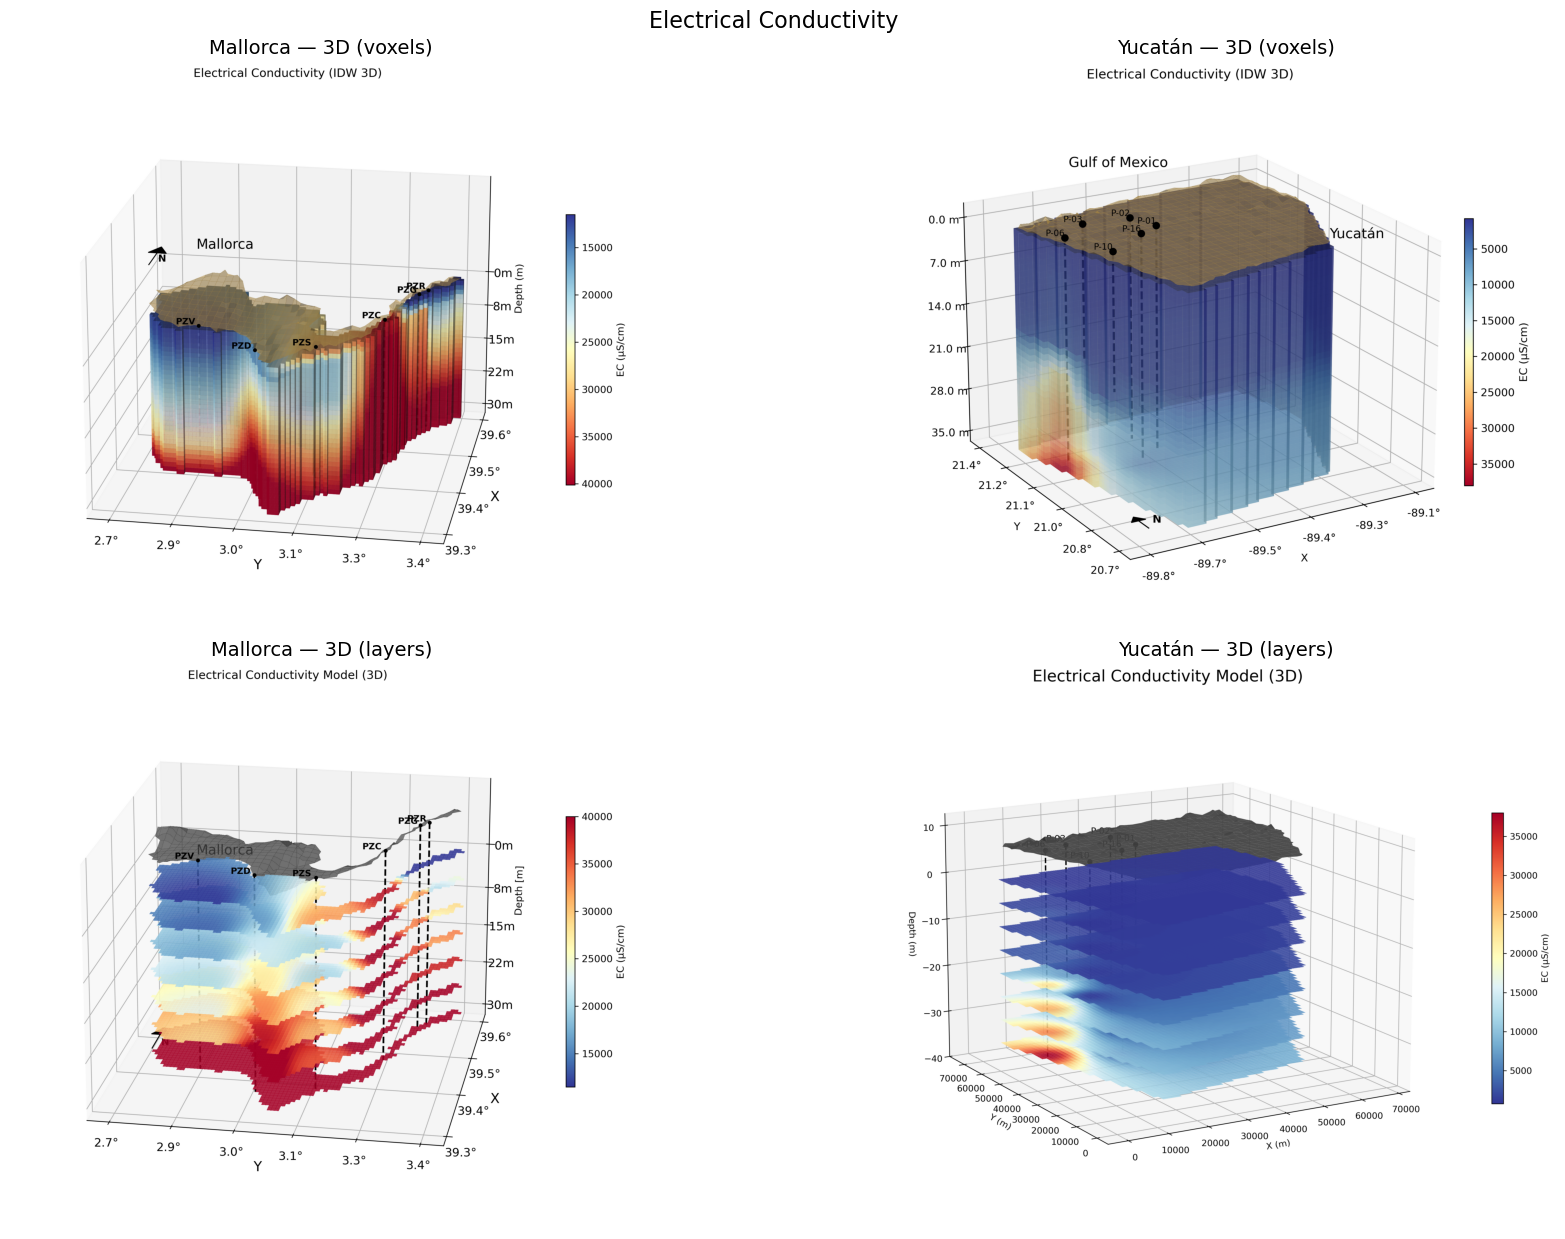

Done -> Saved: EC_4panel_Mallorca_left_Yucatan_right.png


In [8]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ----------------------------
# Config: input figure files
# ----------------------------
MALLORCA_VOX = "6_3D_M.png"
MALLORCA_LAYERS = "6_3D_M_layers.png"

YUCATAN_VOX = "6_3D_Y.png"

# In your last script the layers figure was saved as "6_capas_M.png" (even though it's Yucatán).
# If you renamed it to "6_capas_Y.png", this will still work (automatic fallback).
YUCATAN_LAYERS_CANDIDATES = ["6_capas_Y.png", "6_capas_M.png"]

OUTPUT = "EC_4panel_Mallorca_left_Yucatan_right.png"


def find_existing(candidates):
    for f in candidates:
        if os.path.exists(f):
            return f
    raise FileNotFoundError(
        "None of these files were found:\n  - " + "\n  - ".join(candidates)
    )


def check_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")


# ----------------------------
# Validate inputs
# ----------------------------
check_exists(MALLORCA_VOX)
check_exists(MALLORCA_LAYERS)
check_exists(YUCATAN_VOX)
YUCATAN_LAYERS = find_existing(YUCATAN_LAYERS_CANDIDATES)

# ----------------------------
# Load images
# ----------------------------
img_M_vox = mpimg.imread(MALLORCA_VOX)
img_M_layers = mpimg.imread(MALLORCA_LAYERS)
img_Y_vox = mpimg.imread(YUCATAN_VOX)
img_Y_layers = mpimg.imread(YUCATAN_LAYERS)

# ----------------------------
# Create a single 2x2 figure
# Left = Mallorca ; Right = Yucatán
# ----------------------------
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(18, 12),
    constrained_layout=True
)

# Top-left: Mallorca voxels
axes[0, 0].imshow(img_M_vox)
axes[0, 0].set_title("Mallorca — 3D (voxels)", fontsize=14)
axes[0, 0].axis("off")

# Bottom-left: Mallorca layers
axes[1, 0].imshow(img_M_layers)
axes[1, 0].set_title("Mallorca — 3D (layers)", fontsize=14)
axes[1, 0].axis("off")

# Top-right: Yucatán voxels
axes[0, 1].imshow(img_Y_vox)
axes[0, 1].set_title("Yucatán — 3D (voxels)", fontsize=14)
axes[0, 1].axis("off")

# Bottom-right: Yucatán layers
axes[1, 1].imshow(img_Y_layers)
axes[1, 1].set_title("Yucatán — 3D (layers)", fontsize=14)
axes[1, 1].axis("off")

# Overall title (optional)
fig.suptitle(
    "Electrical Conductivity",
    fontsize=16,
    y=1.02
)

# Save & show
fig.savefig(OUTPUT, dpi=300, bbox_inches="tight")
plt.show()

print(f"Done -> Saved: {OUTPUT}")

/var/folders/f6/wfrnxqf108nbx2nvsph0n70h0000gn/T/ipykernel_37394/1876131005.py:140: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


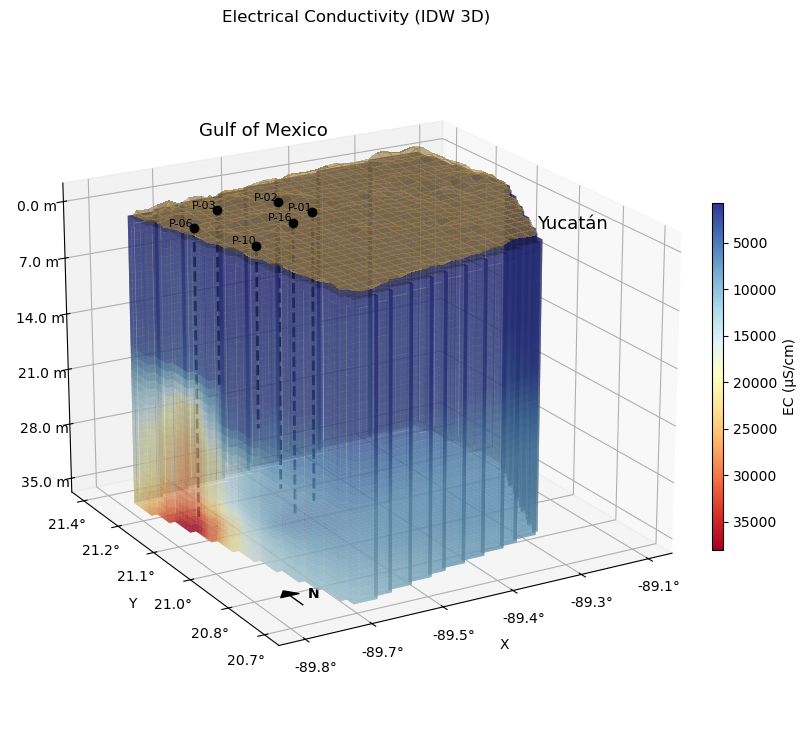

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from shapely import contains_xy, force_2d
from matplotlib import cm
from pyproj import CRS
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- Lectura de datos de sondas ---
df = pd.read_excel("../datos_.xlsx", "Hoja4",usecols=["EST sonda","x","y","Profundidad    (m)","Conductividad corregida"])
df = df.rename(columns={"Profundidad    (m)": "Prof","Conductividad corregida": "Cond"})
for c in ["x", "y", "Prof", "Cond"]:df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df = df.dropna(subset=["x", "y", "Prof", "Cond"])

# --- Área de trabajo (shapefile) ---
g = gpd.read_file("../__QGIS/area_Y.shp")
g["geometry"] = g.geometry.apply(force_2d)
xmin, ymin, xmax, ymax = g.total_bounds
nx = 60
ny = max(20, int(nx * (ymax - ymin) / max(1e-9, (xmax - xmin))))
Xll, Yll = np.meshgrid(np.linspace(xmin, xmax, nx),np.linspace(ymin, ymax, ny))
geom_union = g.union_all() if hasattr(g, "union_all") else g.unary_union
mask = contains_xy(geom_union, Xll, Yll)

# --- MDT ---
with rasterio.open("../__QGIS/MDT_MEX.tif") as r:S = np.array([v[0] for v in r.sample(np.c_[Xll.ravel(), Yll.ravel()])]).reshape(Xll.shape)
S = np.where(mask & np.isfinite(S), S, np.nan)

# --- Interpolación IDW en X-Y para niveles de profundidad ---
def idw(xy, v, Xg, Yg, p=2, eps=1e-12):
    xy, v = np.asarray(xy), np.asarray(v)
    dx, dy = Xg[..., None] - xy[:, 0], Yg[..., None] - xy[:, 1]
    w = 1.0 / ((dx*dx + dy*dy + eps)**(p/2))
    return (w * v).sum(2) / w.sum(2)

depth_targets = np.arange(0, 40.000001, 5.0)
g_by = df.sort_values(["EST sonda", "Prof"]).groupby("EST sonda")

slices, valid_depths = [], []
for d in depth_targets:
    xy, vv = [], []
    for _, gpo in g_by:
        if gpo.Prof.min() <= d <= gpo.Prof.max():
            xy.append([gpo.x.iloc[0], gpo.y.iloc[0]])
            vv.append(np.interp(d, gpo.Prof.to_numpy(), gpo.Cond.to_numpy()))
    if len(vv) >= 3:
        Z = np.where(mask, idw(np.asarray(xy), np.asarray(vv), Xll, Yll), np.nan)
        slices.append(Z)
        valid_depths.append(d)

cond3d = np.stack([z.T for z in slices], axis=-1)  # (nx, ny, nz_coarse)

# --- Refinar a pasos de 1 m en profundidad ---
new_depths = np.arange(valid_depths[0], valid_depths[-1] + 1e-9, 1.0)
nz = len(new_depths)
cond3d_hi = np.full((nx, ny, nz), np.nan)

for ix in range(nx):
    for iy in range(ny):
        col = cond3d[ix, iy, :]
        if np.any(np.isfinite(col)):
            cond3d_hi[ix, iy, :] = np.interp(new_depths, valid_depths, col, left=np.nan, right=np.nan)

cond3d = cond3d_hi
filled = np.isfinite(cond3d)

norm = plt.Normalize(vmin=np.nanmin(cond3d), vmax=np.nanmax(cond3d))

# --- MODELO 3D de conductividad ---
fc = cm.RdYlBu_r(norm(np.nan_to_num(cond3d, nan=np.nanmin(cond3d))))
fc[..., 3] = np.where(filled, 0.6, 0.0)

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")
ax.voxels(filled, facecolors=fc, edgecolor="k", linewidth=0)
sm = cm.ScalarMappable(norm=norm, cmap=cm.RdYlBu_r)
sm.set_array(cond3d[np.isfinite(cond3d)])
cbar = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.5, aspect=30, label="EC (µS/cm)")
cbar.ax.invert_yaxis()
z_ticks = np.linspace(0, nz-1, min(nz, 6)).astype(int)
xt = np.linspace(0, nx-1, min(nx, 6)).astype(int)
yt = np.linspace(0, ny-1, min(ny, 6)).astype(int)

ax.set(xticks=xt,yticks=yt,zticks=z_ticks,zticklabels=[f"{new_depths[i]:.1f} m" for i in z_ticks],xlabel="X",ylabel="Y",title="Electrical Conductivity (IDW 3D)")
ax.set_xticklabels([f"{Xll[0, i]:.1f}°"  for i in xt])
ax.set_yticklabels([f"{Yll[j, 0]:.1f}°" for j in yt])

# --- Superficie MDT en el modelo ---
Xsurf, Ysurf = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")
Smin, Smax = np.nanmin(S), np.nanmax(S)
S_norm = (S - Smin) / max(1e-9, (Smax - Smin))
ax.plot_surface(Xsurf,Ysurf,-1.5 * S_norm,color=(0.8, 0.65, 0.35, 0.6),edgecolor="none",linewidth=0,antialiased=False,shade=True)

# --- Etiqueta 1: Golfo de México ---
ix = int(np.nanargmin(np.abs(Xll[0] - -89.5)));iy = int(np.nanargmin(np.abs(Yll[:, 0] - 21.5)))
if not np.isfinite(S_norm[iy, ix]):yy, xx = np.argwhere(np.isfinite(S_norm)).T;k = np.argmin((xx - ix)**2 + (yy - iy)**2);ix, iy = int(xx[k]), int(yy[k])
z0 = -1.5 * S_norm[iy, ix] - 5
ax.text(ix, iy, z0, "Gulf of Mexico", ha="center", va="bottom", clip_on=False, fontsize=13)

# --- Etiqueta 2: Yucatán ---
ix = int(np.nanargmin(np.abs(Xll[0] + 89.1)));  iy = int(np.nanargmin(np.abs(Yll[:, 0] - 20.78)))
if not np.isfinite(S_norm[iy, ix]):yy, xx = np.argwhere(np.isfinite(S_norm)).T; k = np.argmin((xx - ix)**2 + (yy - iy)**2); ix, iy = int(xx[k]), int(yy[k])
z0 = -1.5 * S_norm[iy, ix] + 0
ax.text(ix, iy, z0, "Yucatán", ha="left", va="bottom", clip_on=False, fontsize=13)

# Norte
ix_anchor = nx * 0.01;iy_anchor = ny * 0.1; iz_top = 35;arrow_scale_idx = 2 
p1 = (ix_anchor + arrow_scale_idx * 0.5, iy_anchor, iz_top)
p2 = (ix_anchor + arrow_scale_idx * 2.0, iy_anchor, iz_top)
p3 = (ix_anchor + arrow_scale_idx * 1.25, iy_anchor + arrow_scale_idx, iz_top)
ax.add_collection3d(Poly3DCollection([[p1, p2, p3]], edgecolor="k", facecolor="k", linewidths=1))
x_mid = ix_anchor + arrow_scale_idx * 1.25
y_end = iy_anchor - arrow_scale_idx * 2
ax.plot([x_mid, x_mid], [iy_anchor, y_end], [iz_top, iz_top], color="k", lw=1)
y_text = y_end + arrow_scale_idx * 0.25
ax.text(x_mid+ arrow_scale_idx * 1.01, y_text, iz_top, "N", color="k", fontsize=10, fontweight="bold", ha="center", va="bottom", clip_on=False)

# --- Representación de las sondas ---
for est, gpo in df.groupby("EST sonda"):
    x_est = gpo.x.iloc[0];y_est = gpo.y.iloc[0]
    ix = int(np.nanargmin(np.abs(Xll[0] - x_est)));iy = int(np.nanargmin(np.abs(Yll[:, 0] - y_est)))
    if not np.isfinite(S_norm[iy, ix]):
        yy, xx = np.argwhere(np.isfinite(S_norm)).T
        k = np.argmin((xx - ix)**2 + (yy - iy)**2)
        ix, iy = int(xx[k]), int(yy[k])
    z_top = -1.5 * S_norm[iy, ix]
    d_max = gpo.Prof.max()
    d_clamped = np.clip(d_max, new_depths[0], new_depths[-1])
    iz_bottom = float(np.interp(d_clamped, new_depths, np.arange(nz)))
    ax.plot([ix, ix],[iy, iy],[z_top, iz_bottom],"--",alpha=1,color="k",lw=2,)
    ax.plot([ix],[iy],-1,"o",color="k",alpha=1,lw=1,zorder=10000000,)
    for xg, yg, zg, name in zip([ix], [iy], [-1], [gpo["EST sonda"].iloc[0]]):
        ax.text(xg, yg, zg, str(name),ha="right", va="bottom", fontsize=8,zorder=10000000000, clip_on=False)
    
ax.invert_zaxis()
ax.view_init(elev=20, azim=-120)

plt.tight_layout()
fig.savefig("6_3D_Y.png", dpi=300, bbox_inches="tight")
plt.show()


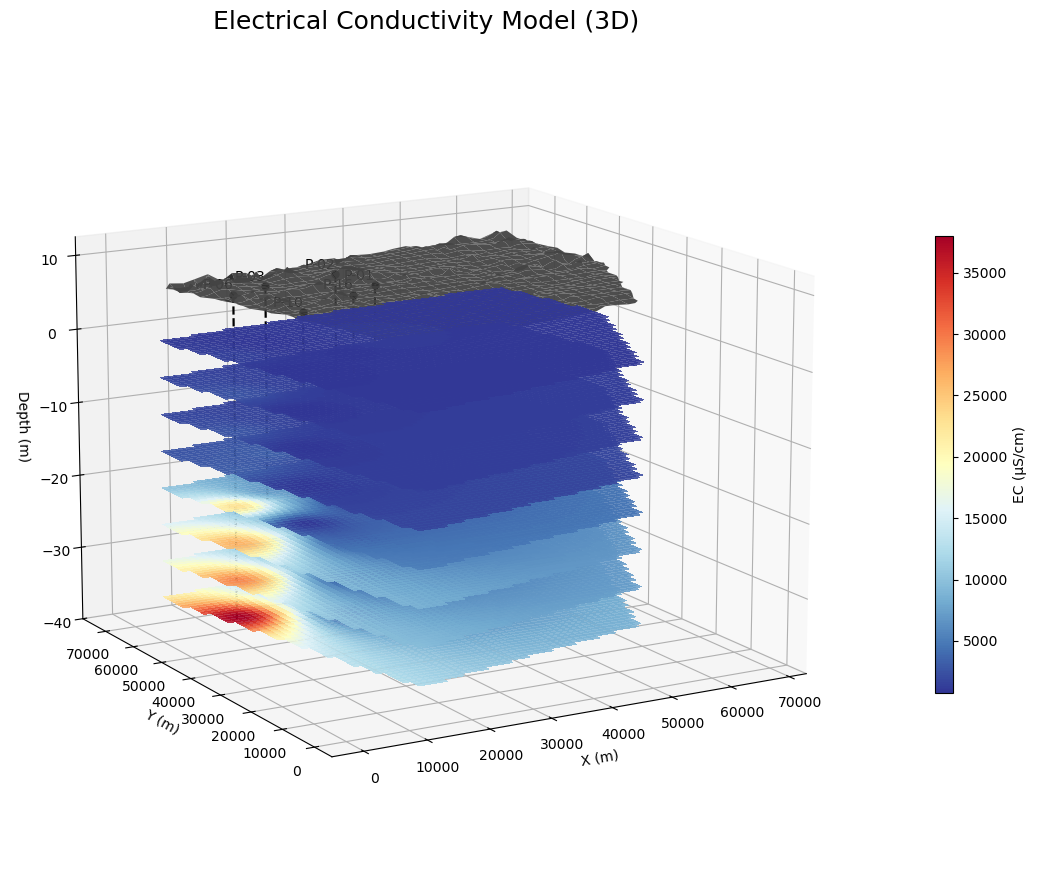

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from shapely import contains_xy, force_2d
from matplotlib import cm
from pyproj import CRS, Transformer
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# -----------------------------
# LECTURA DATOS (igual que tú)
# -----------------------------
df = pd.read_excel("../datos_.xlsx", "Hoja4",
                   usecols=["EST sonda","x","y","Profundidad    (m)","Conductividad corregida"])
df = df.rename(columns={"Profundidad    (m)": "Prof", "Conductividad corregida": "Cond"})
for c in ["x","y","Prof","Cond"]:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df = df.dropna(subset=["x","y","Prof","Cond"])

# -----------------------------
# ÁREA DE TRABAJO
# -----------------------------
g = gpd.read_file("../__QGIS/area_Y.shp")
g["geometry"] = g.geometry.apply(force_2d)

xmin, ymin, xmax, ymax = g.total_bounds
nx = 60
ny = max(20, int(nx * (ymax - ymin) / max(1e-9, (xmax - xmin))))

Xll, Yll = np.meshgrid(np.linspace(xmin, xmax, nx),
                       np.linspace(ymin, ymax, ny))

geom_union = g.union_all() if hasattr(g, "union_all") else g.unary_union
mask = contains_xy(geom_union, Xll, Yll)

# -----------------------------
# MDT (igual que tú)
# -----------------------------
with rasterio.open("../__QGIS/MDT_MEX.tif") as r:
    S = np.array([v[0] for v in r.sample(np.c_[Xll.ravel(), Yll.ravel()])]).reshape(Xll.shape)

S = np.where(mask & np.isfinite(S), S, np.nan)

# -----------------------------
# IDW (igual que tú)
# -----------------------------
def idw(xy, v, Xg, Yg, p=2, eps=1e-12):
    xy, v = np.asarray(xy), np.asarray(v)
    dx, dy = Xg[..., None] - xy[:, 0], Yg[..., None] - xy[:, 1]
    w = 1.0 / ((dx*dx + dy*dy + eps)**(p/2))
    return (w * v).sum(2) / w.sum(2)

depth_targets = np.arange(0, 40.000001, 5.0)
g_by = df.sort_values(["EST sonda", "Prof"]).groupby("EST sonda")

slices, valid_depths = [], []
for d in depth_targets:
    xy, vv = [], []
    for _, gpo in g_by:
        if gpo.Prof.min() <= d <= gpo.Prof.max():
            xy.append([gpo.x.iloc[0], gpo.y.iloc[0]])
            vv.append(np.interp(d, gpo.Prof.to_numpy(), gpo.Cond.to_numpy()))
    if len(vv) >= 3:
        Z = np.where(mask, idw(np.asarray(xy), np.asarray(vv), Xll, Yll), np.nan)
        slices.append(Z)
        valid_depths.append(d)

cond3d = np.stack([z.T for z in slices], axis=-1)  # (nx, ny, nz_coarse)

# Refinar a 1 m
new_depths = np.arange(valid_depths[0], valid_depths[-1] + 1e-9, 1.0)
nz = len(new_depths)
cond3d_hi = np.full((nx, ny, nz), np.nan)

for ix in range(nx):
    for iy in range(ny):
        col = cond3d[ix, iy, :]
        if np.any(np.isfinite(col)):
            cond3d_hi[ix, iy, :] = np.interp(new_depths, valid_depths, col, left=np.nan, right=np.nan)

cond3d = cond3d_hi  # (nx, ny, nz)

# ============================================================
#   FIGURA "CAPAS" (la otra)
# ============================================================

# --- 1) Proyección a metros (UTM 16N) ---
# Si tus X/Y ya están en metros, comenta esto y usa Xll/Yll directamente.
transformer = Transformer.from_crs(CRS.from_epsg(4326), CRS.from_epsg(32616), always_xy=True)

X_m, Y_m = transformer.transform(Xll, Yll)  # grids en metros
x0, y0 = np.nanmin(X_m), np.nanmin(Y_m)
X_m0 = X_m - x0
Y_m0 = Y_m - y0

# Para sondas:
df["X_m"], df["Y_m"] = transformer.transform(df["x"].to_numpy(), df["y"].to_numpy())
df["X_m0"] = df["X_m"] - x0
df["Y_m0"] = df["Y_m"] - y0

# --- 2) Normalización colormap ---
vmin = np.nanmin(cond3d)
vmax = np.nanmax(cond3d)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.RdYlBu_r

# --- 3) MDT arriba (gris) ---
Smin, Smax = np.nanmin(S), np.nanmax(S)
S_norm = (S - Smin) / max(1e-9, (Smax - Smin))

# Escala vertical del MDT (solo estética)
top_z = 8.0                     # altura base del “techo” (m)
terrain_amp = 2.5               # relieve vertical (m)
Z_terrain = top_z + terrain_amp * (S_norm - np.nanmean(S_norm))

# --- 4) Configurar figura ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.set_title("Electrical Conductivity Model (3D)", fontsize=18, pad=14)

# --- 5) Dibujar el terreno ---
ax.plot_surface(
    X_m0, Y_m0, Z_terrain,
    color=(0.35, 0.35, 0.35, 0.95),
    edgecolor="none", linewidth=0, antialiased=True, shade=True
)

# --- 6) Dibujar capas (slices) ---
# Elige cada cuántos metros dibujas una “lámina” (en tu imagen se ven varias, tipo 5 m)
slice_every_m = 5
depths_to_plot = np.arange(new_depths[0], new_depths[-1] + 1e-9, slice_every_m)

for d in depths_to_plot:
    iz = int(np.argmin(np.abs(new_depths - d)))  # índice más cercano
    C = cond3d[:, :, iz].T                       # (ny, nx) para coincidir con X_m0/Y_m0
    valid = np.isfinite(C) & mask

    # plano a profundidad negativa
    Zp = -float(new_depths[iz]) * np.ones_like(X_m0)

    # colores por celda
    fc = cmap(norm(np.nan_to_num(C, nan=vmin)))
    fc[..., 3] = np.where(valid, 0.85, 0.0)      # alpha: visible solo donde hay datos

    ax.plot_surface(
        X_m0, Y_m0, Zp,
        facecolors=fc,
        rstride=1, cstride=1,
        edgecolor="none", linewidth=0,
        antialiased=False, shade=False
    )

# --- 7) Colorbar ---
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array(cond3d[np.isfinite(cond3d)])
cbar = plt.colorbar(sm, ax=ax, pad=0.08, shrink=0.55, aspect=25, label="EC (µS/cm)")

# --- 8) Sondas como líneas verticales ---
for est, gpo in df.groupby("EST sonda"):
    xm = float(gpo["X_m0"].iloc[0])
    ym = float(gpo["Y_m0"].iloc[0])

    # altura del techo en esa posición (aprox. con el grid más cercano)
    ix = int(np.nanargmin(np.abs(X_m0[0, :] - xm)))
    iy = int(np.nanargmin(np.abs(Y_m0[:, 0] - ym)))
    z_top = float(Z_terrain[iy, ix])

    dmax = float(gpo["Prof"].max())
    z_bottom = -np.clip(dmax, new_depths[0], new_depths[-1])

    ax.plot([xm, xm], [ym, ym], [z_top, z_bottom], "--", color="k", lw=1.6, alpha=1.0)
    ax.plot([xm], [ym], [z_top], "o", color="k", ms=5)
    ax.text(xm, ym, z_top + 0.3, str(est), fontsize=10, ha="right", va="bottom")

# --- 9) Ejes / vista ---
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Depth (m)")

# profundidad negativa hacia abajo (ya lo estamos usando)
ax.set_zlim(-new_depths[-1] - 5, top_z + terrain_amp + 2)

# vista parecida a la imagen
ax.view_init(elev=14, azim=-120)

plt.tight_layout()
fig.savefig("EC_layers_3D.png", dpi=300, bbox_inches="tight")
plt.show()


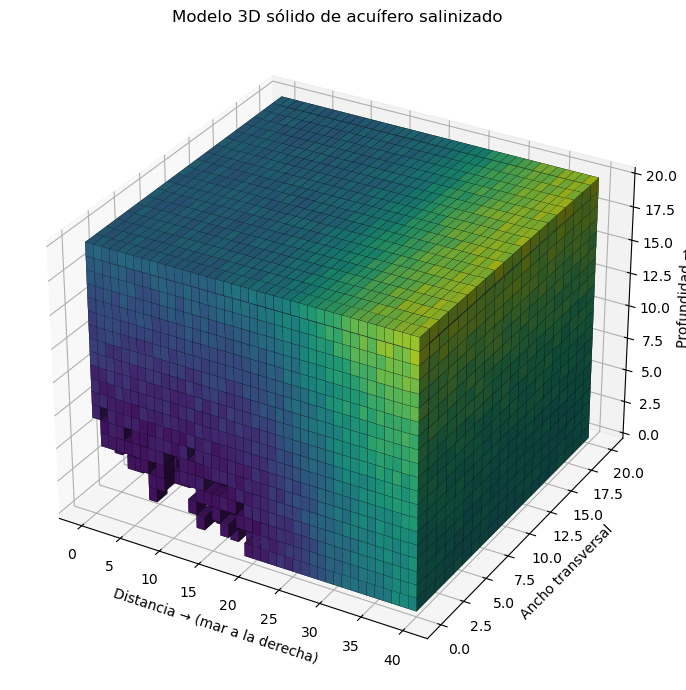

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Definir la resolución y los ejes
nx, ny, nz = 40, 20, 20  # resolución
x = np.linspace(0, 1, nx)  # 0 = interior, 1 = mar (derecha)
y = np.linspace(0, 0.6, ny)
z = np.linspace(0, 1, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Función sigmoide para la salinidad
def sigmoid(a): 
    return 1.0 / (1.0 + np.exp(-a))

# Efecto del mar y la profundidad
mar_effect = sigmoid(10 * (X - 0.7))
depth_effect = 0.8 * (Z ** 1.5)

# Aleatorización para un toque estocástico
np.random.seed(42)
stochastic = 0.08 * (np.random.rand(*X.shape) - 0.5)

# Calcular salinidad
salinity = (0.55 * mar_effect + 0.45 * depth_effect) + stochastic
salinity = np.clip(salinity, 0.0, 1.0)  # entre 0 (dulce) y 1 (salado)

# Crear voxeles a partir de la salinidad
voxels = salinity > 0.05  # umbral para representar como bloques

# Crear colores según la salinidad
colors = plt.cm.viridis(salinity)

# Crear figura 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Crear el gráfico de voxeles 3D
ax.voxels(voxels, facecolors=colors, edgecolor='k', linewidth=0.1)

# Ajustar el título y las etiquetas
ax.set_title('Modelo 3D sólido de acuífero salinizado', pad=0.02)
ax.set_xlabel('Distancia → (mar a la derecha)')
ax.set_ylabel('Ancho transversal')
ax.set_zlabel('Profundidad →')

# Ajustar la vista para darle el efecto de "bloques"
ax.view_init(elev=30, azim=-60)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


/var/folders/f6/wfrnxqf108nbx2nvsph0n70h0000gn/T/ipykernel_27706/1876131005.py:140: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


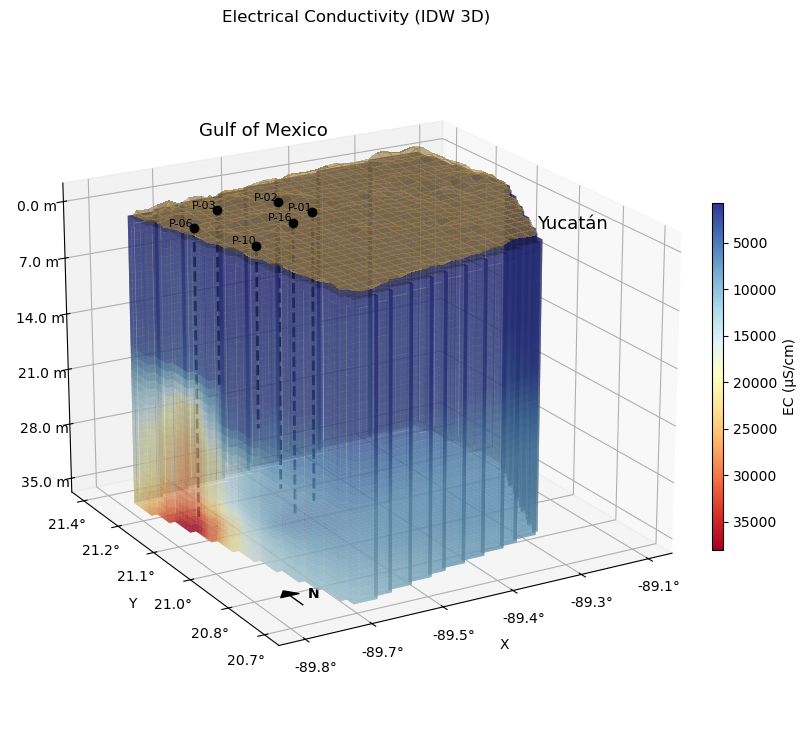

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from shapely import contains_xy, force_2d
from matplotlib import cm
from pyproj import CRS
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- Lectura de datos de sondas ---
df = pd.read_excel("../datos_.xlsx", "Hoja4",usecols=["EST sonda","x","y","Profundidad    (m)","Conductividad corregida"])
df = df.rename(columns={"Profundidad    (m)": "Prof","Conductividad corregida": "Cond"})
for c in ["x", "y", "Prof", "Cond"]:df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df = df.dropna(subset=["x", "y", "Prof", "Cond"])

# --- Área de trabajo (shapefile) ---
g = gpd.read_file("../__QGIS/area_Y.shp")
g["geometry"] = g.geometry.apply(force_2d)
xmin, ymin, xmax, ymax = g.total_bounds
nx = 60
ny = max(20, int(nx * (ymax - ymin) / max(1e-9, (xmax - xmin))))
Xll, Yll = np.meshgrid(np.linspace(xmin, xmax, nx),np.linspace(ymin, ymax, ny))
geom_union = g.union_all() if hasattr(g, "union_all") else g.unary_union
mask = contains_xy(geom_union, Xll, Yll)

# --- MDT ---
with rasterio.open("../__QGIS/MDT_MEX.tif") as r:S = np.array([v[0] for v in r.sample(np.c_[Xll.ravel(), Yll.ravel()])]).reshape(Xll.shape)
S = np.where(mask & np.isfinite(S), S, np.nan)

# --- Interpolación IDW en X-Y para niveles de profundidad ---
def idw(xy, v, Xg, Yg, p=2, eps=1e-12):
    xy, v = np.asarray(xy), np.asarray(v)
    dx, dy = Xg[..., None] - xy[:, 0], Yg[..., None] - xy[:, 1]
    w = 1.0 / ((dx*dx + dy*dy + eps)**(p/2))
    return (w * v).sum(2) / w.sum(2)

depth_targets = np.arange(0, 40.000001, 5.0)
g_by = df.sort_values(["EST sonda", "Prof"]).groupby("EST sonda")

slices, valid_depths = [], []
for d in depth_targets:
    xy, vv = [], []
    for _, gpo in g_by:
        if gpo.Prof.min() <= d <= gpo.Prof.max():
            xy.append([gpo.x.iloc[0], gpo.y.iloc[0]])
            vv.append(np.interp(d, gpo.Prof.to_numpy(), gpo.Cond.to_numpy()))
    if len(vv) >= 3:
        Z = np.where(mask, idw(np.asarray(xy), np.asarray(vv), Xll, Yll), np.nan)
        slices.append(Z)
        valid_depths.append(d)

cond3d = np.stack([z.T for z in slices], axis=-1)  # (nx, ny, nz_coarse)

# --- Refinar a pasos de 1 m en profundidad ---
new_depths = np.arange(valid_depths[0], valid_depths[-1] + 1e-9, 1.0)
nz = len(new_depths)
cond3d_hi = np.full((nx, ny, nz), np.nan)

for ix in range(nx):
    for iy in range(ny):
        col = cond3d[ix, iy, :]
        if np.any(np.isfinite(col)):
            cond3d_hi[ix, iy, :] = np.interp(new_depths, valid_depths, col, left=np.nan, right=np.nan)

cond3d = cond3d_hi
filled = np.isfinite(cond3d)

norm = plt.Normalize(vmin=np.nanmin(cond3d), vmax=np.nanmax(cond3d))

# --- MODELO 3D de conductividad ---
fc = cm.RdYlBu_r(norm(np.nan_to_num(cond3d, nan=np.nanmin(cond3d))))
fc[..., 3] = np.where(filled, 0.6, 0.0)

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")
ax.voxels(filled, facecolors=fc, edgecolor="k", linewidth=0)
sm = cm.ScalarMappable(norm=norm, cmap=cm.RdYlBu_r)
sm.set_array(cond3d[np.isfinite(cond3d)])
cbar = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.5, aspect=30, label="EC (µS/cm)")
cbar.ax.invert_yaxis()
z_ticks = np.linspace(0, nz-1, min(nz, 6)).astype(int)
xt = np.linspace(0, nx-1, min(nx, 6)).astype(int)
yt = np.linspace(0, ny-1, min(ny, 6)).astype(int)

ax.set(xticks=xt,yticks=yt,zticks=z_ticks,zticklabels=[f"{new_depths[i]:.1f} m" for i in z_ticks],xlabel="X",ylabel="Y",title="Electrical Conductivity (IDW 3D)")
ax.set_xticklabels([f"{Xll[0, i]:.1f}°"  for i in xt])
ax.set_yticklabels([f"{Yll[j, 0]:.1f}°" for j in yt])

# --- Superficie MDT en el modelo ---
Xsurf, Ysurf = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")
Smin, Smax = np.nanmin(S), np.nanmax(S)
S_norm = (S - Smin) / max(1e-9, (Smax - Smin))
ax.plot_surface(Xsurf,Ysurf,-1.5 * S_norm,color=(0.8, 0.65, 0.35, 0.6),edgecolor="none",linewidth=0,antialiased=False,shade=True)

# --- Etiqueta 1: Golfo de México ---
ix = int(np.nanargmin(np.abs(Xll[0] - -89.5)));iy = int(np.nanargmin(np.abs(Yll[:, 0] - 21.5)))
if not np.isfinite(S_norm[iy, ix]):yy, xx = np.argwhere(np.isfinite(S_norm)).T;k = np.argmin((xx - ix)**2 + (yy - iy)**2);ix, iy = int(xx[k]), int(yy[k])
z0 = -1.5 * S_norm[iy, ix] - 5
ax.text(ix, iy, z0, "Gulf of Mexico", ha="center", va="bottom", clip_on=False, fontsize=13)

# --- Etiqueta 2: Yucatán ---
ix = int(np.nanargmin(np.abs(Xll[0] + 89.1)));  iy = int(np.nanargmin(np.abs(Yll[:, 0] - 20.78)))
if not np.isfinite(S_norm[iy, ix]):yy, xx = np.argwhere(np.isfinite(S_norm)).T; k = np.argmin((xx - ix)**2 + (yy - iy)**2); ix, iy = int(xx[k]), int(yy[k])
z0 = -1.5 * S_norm[iy, ix] + 0
ax.text(ix, iy, z0, "Yucatán", ha="left", va="bottom", clip_on=False, fontsize=13)

# Norte
ix_anchor = nx * 0.01;iy_anchor = ny * 0.1; iz_top = 35;arrow_scale_idx = 2 
p1 = (ix_anchor + arrow_scale_idx * 0.5, iy_anchor, iz_top)
p2 = (ix_anchor + arrow_scale_idx * 2.0, iy_anchor, iz_top)
p3 = (ix_anchor + arrow_scale_idx * 1.25, iy_anchor + arrow_scale_idx, iz_top)
ax.add_collection3d(Poly3DCollection([[p1, p2, p3]], edgecolor="k", facecolor="k", linewidths=1))
x_mid = ix_anchor + arrow_scale_idx * 1.25
y_end = iy_anchor - arrow_scale_idx * 2
ax.plot([x_mid, x_mid], [iy_anchor, y_end], [iz_top, iz_top], color="k", lw=1)
y_text = y_end + arrow_scale_idx * 0.25
ax.text(x_mid+ arrow_scale_idx * 1.01, y_text, iz_top, "N", color="k", fontsize=10, fontweight="bold", ha="center", va="bottom", clip_on=False)

# --- Representación de las sondas ---
for est, gpo in df.groupby("EST sonda"):
    x_est = gpo.x.iloc[0];y_est = gpo.y.iloc[0]
    ix = int(np.nanargmin(np.abs(Xll[0] - x_est)));iy = int(np.nanargmin(np.abs(Yll[:, 0] - y_est)))
    if not np.isfinite(S_norm[iy, ix]):
        yy, xx = np.argwhere(np.isfinite(S_norm)).T
        k = np.argmin((xx - ix)**2 + (yy - iy)**2)
        ix, iy = int(xx[k]), int(yy[k])
    z_top = -1.5 * S_norm[iy, ix]
    d_max = gpo.Prof.max()
    d_clamped = np.clip(d_max, new_depths[0], new_depths[-1])
    iz_bottom = float(np.interp(d_clamped, new_depths, np.arange(nz)))
    ax.plot([ix, ix],[iy, iy],[z_top, iz_bottom],"--",alpha=1,color="k",lw=2,)
    ax.plot([ix],[iy],-1,"o",color="k",alpha=1,lw=1,zorder=10000000,)
    for xg, yg, zg, name in zip([ix], [iy], [-1], [gpo["EST sonda"].iloc[0]]):
        ax.text(xg, yg, zg, str(name),ha="right", va="bottom", fontsize=8,zorder=10000000000, clip_on=False)
    
ax.invert_zaxis()
ax.view_init(elev=20, azim=-120)

plt.tight_layout()
fig.savefig("6_3D_Y.png", dpi=300, bbox_inches="tight")
plt.show()


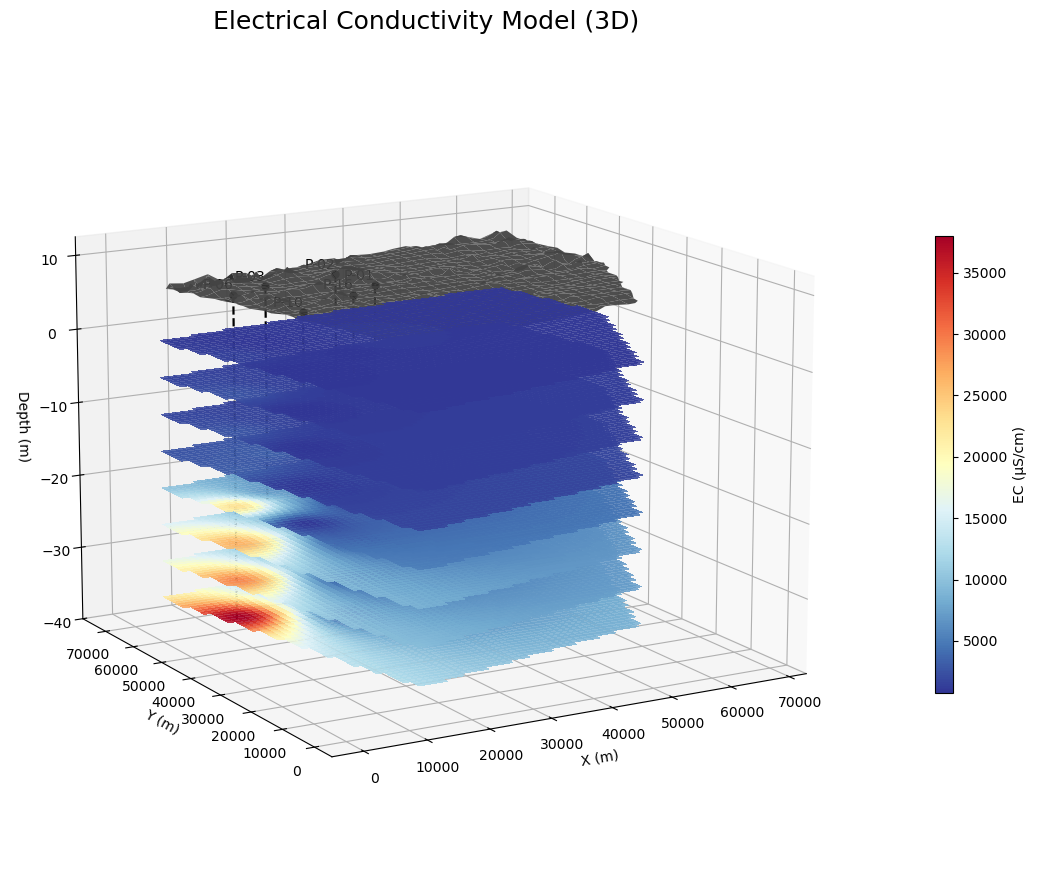

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from shapely import contains_xy, force_2d
from matplotlib import cm
from pyproj import CRS, Transformer
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# -----------------------------
# LECTURA DATOS (igual que tú)
# -----------------------------
df = pd.read_excel("../datos_.xlsx", "Hoja4",
                   usecols=["EST sonda","x","y","Profundidad    (m)","Conductividad corregida"])
df = df.rename(columns={"Profundidad    (m)": "Prof", "Conductividad corregida": "Cond"})
for c in ["x","y","Prof","Cond"]:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df = df.dropna(subset=["x","y","Prof","Cond"])

# -----------------------------
# ÁREA DE TRABAJO
# -----------------------------
g = gpd.read_file("../__QGIS/area_Y.shp")
g["geometry"] = g.geometry.apply(force_2d)

xmin, ymin, xmax, ymax = g.total_bounds
nx = 60
ny = max(20, int(nx * (ymax - ymin) / max(1e-9, (xmax - xmin))))

Xll, Yll = np.meshgrid(np.linspace(xmin, xmax, nx),
                       np.linspace(ymin, ymax, ny))

geom_union = g.union_all() if hasattr(g, "union_all") else g.unary_union
mask = contains_xy(geom_union, Xll, Yll)

# -----------------------------
# MDT (igual que tú)
# -----------------------------
with rasterio.open("../__QGIS/MDT_MEX.tif") as r:
    S = np.array([v[0] for v in r.sample(np.c_[Xll.ravel(), Yll.ravel()])]).reshape(Xll.shape)

S = np.where(mask & np.isfinite(S), S, np.nan)

# -----------------------------
# IDW (igual que tú)
# -----------------------------
def idw(xy, v, Xg, Yg, p=2, eps=1e-12):
    xy, v = np.asarray(xy), np.asarray(v)
    dx, dy = Xg[..., None] - xy[:, 0], Yg[..., None] - xy[:, 1]
    w = 1.0 / ((dx*dx + dy*dy + eps)**(p/2))
    return (w * v).sum(2) / w.sum(2)

depth_targets = np.arange(0, 40.000001, 5.0)
g_by = df.sort_values(["EST sonda", "Prof"]).groupby("EST sonda")

slices, valid_depths = [], []
for d in depth_targets:
    xy, vv = [], []
    for _, gpo in g_by:
        if gpo.Prof.min() <= d <= gpo.Prof.max():
            xy.append([gpo.x.iloc[0], gpo.y.iloc[0]])
            vv.append(np.interp(d, gpo.Prof.to_numpy(), gpo.Cond.to_numpy()))
    if len(vv) >= 3:
        Z = np.where(mask, idw(np.asarray(xy), np.asarray(vv), Xll, Yll), np.nan)
        slices.append(Z)
        valid_depths.append(d)

cond3d = np.stack([z.T for z in slices], axis=-1)  # (nx, ny, nz_coarse)

# Refinar a 1 m
new_depths = np.arange(valid_depths[0], valid_depths[-1] + 1e-9, 1.0)
nz = len(new_depths)
cond3d_hi = np.full((nx, ny, nz), np.nan)

for ix in range(nx):
    for iy in range(ny):
        col = cond3d[ix, iy, :]
        if np.any(np.isfinite(col)):
            cond3d_hi[ix, iy, :] = np.interp(new_depths, valid_depths, col, left=np.nan, right=np.nan)

cond3d = cond3d_hi  # (nx, ny, nz)

# ============================================================
#   FIGURA "CAPAS" (la otra)
# ============================================================

# --- 1) Proyección a metros (UTM 16N) ---
# Si tus X/Y ya están en metros, comenta esto y usa Xll/Yll directamente.
transformer = Transformer.from_crs(CRS.from_epsg(4326), CRS.from_epsg(32616), always_xy=True)

X_m, Y_m = transformer.transform(Xll, Yll)  # grids en metros
x0, y0 = np.nanmin(X_m), np.nanmin(Y_m)
X_m0 = X_m - x0
Y_m0 = Y_m - y0

# Para sondas:
df["X_m"], df["Y_m"] = transformer.transform(df["x"].to_numpy(), df["y"].to_numpy())
df["X_m0"] = df["X_m"] - x0
df["Y_m0"] = df["Y_m"] - y0

# --- 2) Normalización colormap ---
vmin = np.nanmin(cond3d)
vmax = np.nanmax(cond3d)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.RdYlBu_r

# --- 3) MDT arriba (gris) ---
Smin, Smax = np.nanmin(S), np.nanmax(S)
S_norm = (S - Smin) / max(1e-9, (Smax - Smin))

# Escala vertical del MDT (solo estética)
top_z = 8.0                     # altura base del “techo” (m)
terrain_amp = 2.5               # relieve vertical (m)
Z_terrain = top_z + terrain_amp * (S_norm - np.nanmean(S_norm))

# --- 4) Configurar figura ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.set_title("Electrical Conductivity Model (3D)", fontsize=18, pad=14)

# --- 5) Dibujar el terreno ---
ax.plot_surface(
    X_m0, Y_m0, Z_terrain,
    color=(0.35, 0.35, 0.35, 0.95),
    edgecolor="none", linewidth=0, antialiased=True, shade=True
)

# --- 6) Dibujar capas (slices) ---
# Elige cada cuántos metros dibujas una “lámina” (en tu imagen se ven varias, tipo 5 m)
slice_every_m = 5
depths_to_plot = np.arange(new_depths[0], new_depths[-1] + 1e-9, slice_every_m)

for d in depths_to_plot:
    iz = int(np.argmin(np.abs(new_depths - d)))  # índice más cercano
    C = cond3d[:, :, iz].T                       # (ny, nx) para coincidir con X_m0/Y_m0
    valid = np.isfinite(C) & mask

    # plano a profundidad negativa
    Zp = -float(new_depths[iz]) * np.ones_like(X_m0)

    # colores por celda
    fc = cmap(norm(np.nan_to_num(C, nan=vmin)))
    fc[..., 3] = np.where(valid, 0.85, 0.0)      # alpha: visible solo donde hay datos

    ax.plot_surface(
        X_m0, Y_m0, Zp,
        facecolors=fc,
        rstride=1, cstride=1,
        edgecolor="none", linewidth=0,
        antialiased=False, shade=False
    )

# --- 7) Colorbar ---
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array(cond3d[np.isfinite(cond3d)])
cbar = plt.colorbar(sm, ax=ax, pad=0.08, shrink=0.55, aspect=25, label="EC (µS/cm)")

# --- 8) Sondas como líneas verticales ---
for est, gpo in df.groupby("EST sonda"):
    xm = float(gpo["X_m0"].iloc[0])
    ym = float(gpo["Y_m0"].iloc[0])

    # altura del techo en esa posición (aprox. con el grid más cercano)
    ix = int(np.nanargmin(np.abs(X_m0[0, :] - xm)))
    iy = int(np.nanargmin(np.abs(Y_m0[:, 0] - ym)))
    z_top = float(Z_terrain[iy, ix])

    dmax = float(gpo["Prof"].max())
    z_bottom = -np.clip(dmax, new_depths[0], new_depths[-1])

    ax.plot([xm, xm], [ym, ym], [z_top, z_bottom], "--", color="k", lw=1.6, alpha=1.0)
    ax.plot([xm], [ym], [z_top], "o", color="k", ms=5)
    ax.text(xm, ym, z_top + 0.3, str(est), fontsize=10, ha="right", va="bottom")

# --- 9) Ejes / vista ---
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Depth (m)")

# profundidad negativa hacia abajo (ya lo estamos usando)
ax.set_zlim(-new_depths[-1] - 5, top_z + terrain_amp + 2)

# vista parecida a la imagen
ax.view_init(elev=14, azim=-120)

plt.tight_layout()
fig.savefig("EC_layers_3D.png", dpi=300, bbox_inches="tight")
plt.show()
